# 02. Baseline-модель

В этом ноутбуке строится baseline-модель для задачи предсказания отказа промышленного оборудования.

Baseline нужен, чтобы получить начальную точку сравнения для дальнейших экспериментов.

В качестве baseline используется простая модель `LogisticRegression` без feature engineering.

Особенности baseline:

- используются только исходные признаки;
- исключаются идентификаторы `UDI`, `Product ID`;
- исключаются признаки типов отказов `TWF`, `HDF`, `PWF`, `OSF`, `RNF`, чтобы избежать data leakage;
- категориальный признак `Type` кодируется с помощью One-Hot Encoding;
- числовые признаки масштабируются с помощью StandardScaler;
- данные делятся на train/validation/test в пропорции 70/15/15 со стратификацией.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

In [2]:
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ai4i2020.csv"

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH

WindowsPath('C:/Users/vladp/Documents/MLProjects/hseml-group-project-vlad010305/data/raw/ai4i2020.csv')

In [3]:
from src.preprocessing import split_features_target, make_train_val_test_split
from src.modeling import evaluate_classifier

## 1. Загрузка данных

In [4]:
df = pd.read_csv(DATA_PATH)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1000,308.6000,1551,42.8000,0,0,0,0,0,0,0
1,2,L47181,L,298.2000,308.7000,1408,46.3000,3,0,0,0,0,0,0
2,3,L47182,L,298.1000,308.5000,1498,49.4000,5,0,0,0,0,0,0
3,4,L47183,L,298.2000,308.6000,1433,39.5000,7,0,0,0,0,0,0
4,5,L47184,L,298.2000,308.7000,1408,40.0000,9,0,0,0,0,0,0


## 2. Разделение на признаки и целевую переменную

Целевая переменная — `Machine failure`.

Из признаков исключаются:

- `UDI` и `Product ID`, так как это идентификаторы;
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`, так как это индикаторы типов отказа, которые могут привести к data leakage.

In [5]:
X, y = split_features_target(df)

X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1000,308.6000,1551,42.8000,0
1,L,298.2000,308.7000,1408,46.3000,3
2,L,298.1000,308.5000,1498,49.4000,5
3,L,298.2000,308.6000,1433,39.5000,7
4,L,298.2000,308.7000,1408,40.0000,9


In [6]:
X.shape, y.shape

((10000, 6), (10000,))

In [7]:
y.value_counts(normalize=True).sort_index()

Machine failure
0   0.9661
1   0.0339
Name: proportion, dtype: float64

## 3. Train / validation / test split

Данные делятся на train/validation/test в пропорции 70/15/15.

Стратификация используется для сохранения доли отказов во всех выборках.

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test = make_train_val_test_split(X, y)

X_train.shape, X_val.shape, X_test.shape

((7000, 6), (1500, 6), (1500, 6))

In [9]:
split_distribution = pd.DataFrame(
    {
        "train": y_train.value_counts(normalize=True).sort_index(),
        "validation": y_val.value_counts(normalize=True).sort_index(),
        "test": y_test.value_counts(normalize=True).sort_index(),
    }
)

split_distribution

,train,validation,test
Machine failure,,,
0,0.9661,0.9660,0.9660
1,0.0339,0.0340,0.0340


## 4. Подготовка признаков

В baseline-модели используется стандартная предобработка:

- числовые признаки масштабируются с помощью `StandardScaler`;
- категориальный признак `Type` кодируется с помощью `OneHotEncoder`.

Все преобразования объединены в `sklearn Pipeline`, чтобы избежать data leakage.

In [10]:
categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features, numeric_features

(['Type'],
 ['Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]'])

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Обучение baseline-модели

В качестве baseline используется `LogisticRegression`.

Это простая линейная модель, которая подходит для начальной оценки качества и дальнейшего сравнения с более сложными моделями.

In [12]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [13]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 6. Оценка baseline-модели на validation

Так как задача является несбалансированной, основное внимание уделяется PR-AUC, F1-score, Recall и Precision. Accuracy не используется как основная метрика.

In [14]:
baseline_val_metrics = evaluate_classifier(
    baseline_model,
    X_val,
    y_val,
)

baseline_val_metrics

{'PR-AUC': 0.3565343390600447,
 'ROC-AUC': 0.8427448273995589,
 'F1': 0.26229508196721313,
 'Precision': 0.8,
 'Recall': 0.1568627450980392,
 'TN': np.int64(1447),
 'FP': np.int64(2),
 'FN': np.int64(43),
 'TP': np.int64(8)}

In [15]:
baseline_results = pd.DataFrame(
    [
        {
            "experiment": "baseline",
            "model": "Logistic Regression",
            "features": "raw features",
            **baseline_val_metrics,
        }
    ]
)

baseline_results

,experiment,model,features,PR-AUC,ROC-AUC,F1,Precision,Recall,TN,FP,FN,TP
0,baseline,Logistic Regression,raw features,0.3565,0.8427,0.2623,0.8000,0.1569,1447,2,43,8


Baseline-модель показывает высокий Precision, но низкий Recall. Это означает, что модель редко предсказывает отказ оборудования, но если предсказывает, то часто оказывается права.

При этом модель пропускает значительную часть реальных отказов: из 51 отказа на validation-выборке найдено только 8. Поэтому для задачи предиктивного обслуживания такой baseline недостаточен: важно не только избегать ложных тревог, но и находить больше реальных отказов.

Дальше будет проверен вариант с `class_weight='balanced'`, который учитывает дисбаланс классов.

## 7. Confusion matrix

Посмотрим, как baseline-модель ошибается на validation-выборке.

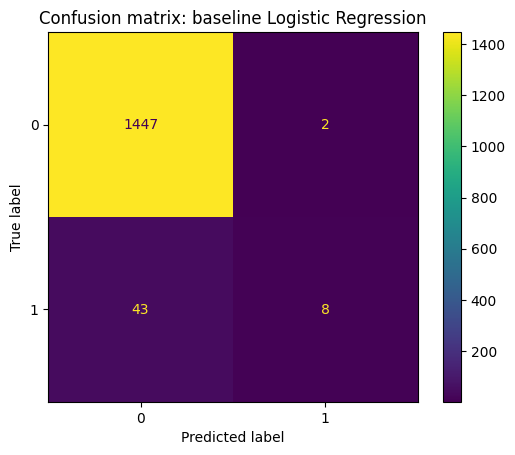

In [16]:
ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_val,
    y_val,
)

plt.title("Confusion matrix: baseline Logistic Regression")
plt.show()

## 8. PR-кривая и ROC-кривая

Для несбалансированной классификации PR-кривая особенно важна, так как она показывает качество модели на положительном классе `Machine failure = 1`.

ROC-AUC также используется как дополнительная метрика, но при сильном дисбалансе классов она может выглядеть более оптимистично.

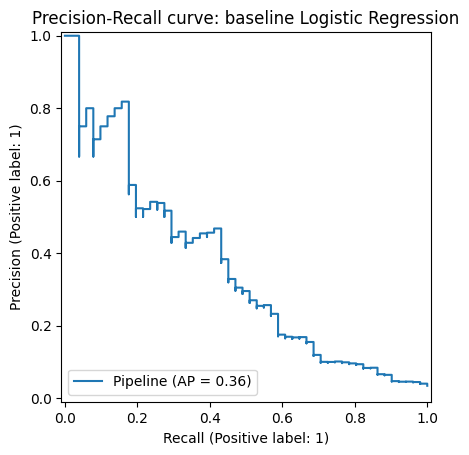

In [17]:
PrecisionRecallDisplay.from_estimator(
    baseline_model,
    X_val,
    y_val,
)

plt.title("Precision-Recall curve: baseline Logistic Regression")
plt.show()

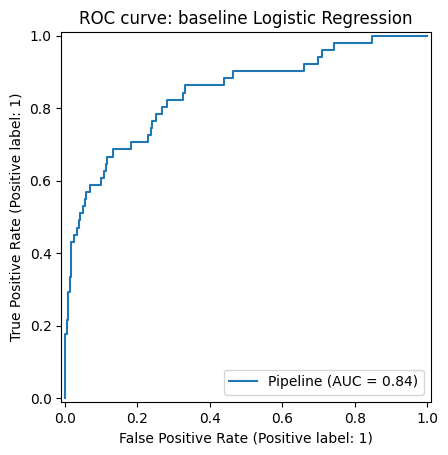

In [18]:
RocCurveDisplay.from_estimator(
    baseline_model,
    X_val,
    y_val,
)

plt.title("ROC curve: baseline Logistic Regression")
plt.show()

PR-кривая показывает, что baseline-модель ограниченно справляется с выделением редкого положительного класса. При росте Recall значение Precision быстро снижается.

ROC-AUC у baseline-модели достаточно высокий, однако при сильном дисбалансе классов ROC-AUC может выглядеть более оптимистично. Поэтому для данной задачи основное внимание уделяется PR-AUC, Recall и F1-score.

## 9. Дополнительный baseline с учётом дисбаланса классов

Так как положительный класс встречается редко, проверим вариант логистической регрессии с параметром `class_weight='balanced'`.

Этот параметр увеличивает вес редкого класса при обучении модели. Ожидается, что Recall может вырасти, но Precision может снизиться.

In [19]:
balanced_baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

balanced_baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [20]:
balanced_baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [21]:
balanced_baseline_val_metrics = evaluate_classifier(
    balanced_baseline_model,
    X_val,
    y_val,
)

balanced_baseline_val_metrics

{'PR-AUC': 0.30829500503384627,
 'ROC-AUC': 0.84022787859105,
 'F1': 0.1917808219178082,
 'Precision': 0.11146496815286625,
 'Recall': 0.6862745098039216,
 'TN': np.int64(1170),
 'FP': np.int64(279),
 'FN': np.int64(16),
 'TP': np.int64(35)}

Модель с `class_weight='balanced'` стала значительно чаще находить реальные отказы: Recall вырос с 0.1569 до 0.6863. Количество пропущенных отказов снизилось с 43 до 16.

Однако за это модель заплатила большим количеством ложных срабатываний: FP выросло с 2 до 279, а Precision снизился с 0.8000 до 0.1115.

Таким образом, `class_weight='balanced'` помогает находить больше отказов, но делает модель слишком склонной предсказывать положительный класс. По PR-AUC и F1 обычная Logistic Regression оказалась лучше, поэтому balanced baseline не является однозначно лучшим решением.

## 10. Сравнение baseline-моделей

Сравним обычную логистическую регрессию и логистическую регрессию с учётом дисбаланса классов.

In [22]:
baseline_comparison = pd.DataFrame(
    [
        {
            "experiment": "baseline",
            "model": "Logistic Regression",
            "features": "raw features",
            **baseline_val_metrics,
        },
        {
            "experiment": "baseline_balanced",
            "model": "Logistic Regression",
            "features": "raw features",
            **balanced_baseline_val_metrics,
        },
    ]
)

baseline_comparison

,experiment,model,features,PR-AUC,ROC-AUC,F1,Precision,Recall,TN,FP,FN,TP
0,baseline,Logistic Regression,raw features,0.3565,0.8427,0.2623,0.8000,0.1569,1447,2,43,8
1,baseline_balanced,Logistic Regression,raw features,0.3083,0.8402,0.1918,0.1115,0.6863,1170,279,16,35


In [23]:
baseline_comparison.sort_values("PR-AUC", ascending=False)

,experiment,model,features,PR-AUC,ROC-AUC,F1,Precision,Recall,TN,FP,FN,TP
0,baseline,Logistic Regression,raw features,0.3565,0.8427,0.2623,0.8000,0.1569,1447,2,43,8
1,baseline_balanced,Logistic Regression,raw features,0.3083,0.8402,0.1918,0.1115,0.6863,1170,279,16,35


Обычная `LogisticRegression` показала лучший PR-AUC и F1-score среди двух baseline-вариантов:

- PR-AUC = 0.3565;
- F1 = 0.2623;
- Precision = 0.8000;
- Recall = 0.1569.

Эта модель очень редко ошибочно предсказывает отказ, но пропускает большую часть реальных отказов.

`LogisticRegression` с `class_weight='balanced'` показала более высокий Recall:

- Recall = 0.6863;
- TP = 35;
- FN = 16.

Однако Precision резко снизился до 0.1115, а количество ложных срабатываний выросло до 279. Поэтому balanced baseline лучше находит отказы, но делает слишком много ложных тревог.

В дальнейших экспериментах нужно искать более удачный баланс между Recall и Precision.

## 11. Confusion matrix для balanced baseline

Посмотрим, как изменились ошибки модели после учёта дисбаланса классов.

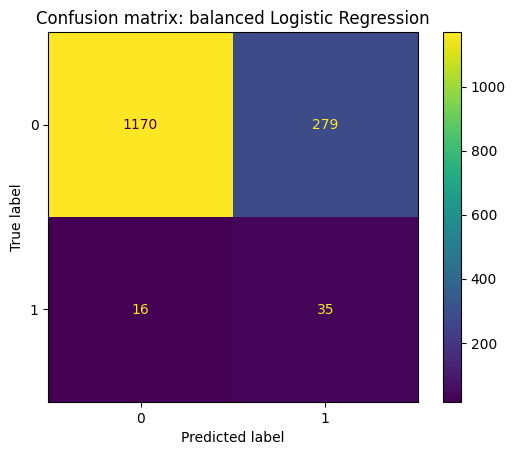

In [24]:
ConfusionMatrixDisplay.from_estimator(
    balanced_baseline_model,
    X_val,
    y_val,
)

plt.title("Confusion matrix: balanced Logistic Regression")
plt.show()

После добавления `class_weight='balanced'` модель стала чаще предсказывать положительный класс. Это позволило уменьшить количество пропущенных отказов, но привело к росту числа ложных срабатываний.

## 12. PR-кривая и ROC-кривая для balanced baseline

Построим PR-кривую и ROC-кривую для модели с учётом дисбаланса классов.

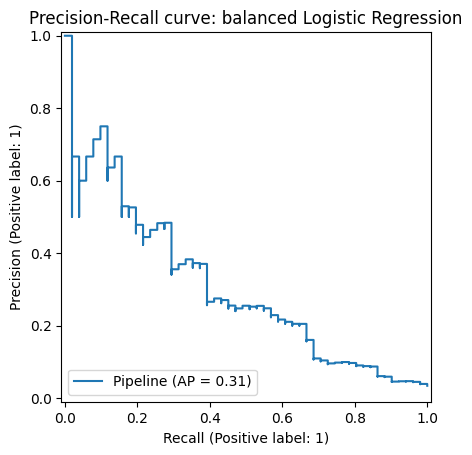

In [25]:
PrecisionRecallDisplay.from_estimator(
    balanced_baseline_model,
    X_val,
    y_val,
)

plt.title("Precision-Recall curve: balanced Logistic Regression")
plt.show()

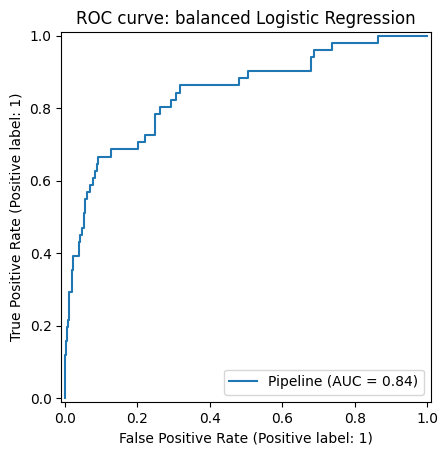

In [26]:
RocCurveDisplay.from_estimator(
    balanced_baseline_model,
    X_val,
    y_val,
)

plt.title("ROC curve: balanced Logistic Regression")
plt.show()

PR-кривая для balanced baseline показывает AP около 0.31, что ниже, чем у обычной логистической регрессии. Несмотря на рост Recall, качество модели с точки зрения баланса Precision и Recall ухудшилось.

ROC-AUC остался примерно на том же уровне, около 0.84. Это подтверждает, что ROC-AUC при сильном дисбалансе классов может быть недостаточно информативной метрикой для выбора модели.

## 13. Сохранение таблицы результатов

Сохраним таблицу с результатами baseline-экспериментов. Она будет использоваться для сравнения с дальнейшими моделями.

In [27]:
RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "baseline_results.csv"

baseline_comparison.to_csv(RESULTS_PATH, index=False)

RESULTS_PATH

WindowsPath('C:/Users/vladp/Documents/MLProjects/hseml-group-project-vlad010305/data/processed/baseline_results.csv')

In [28]:
pd.read_csv(RESULTS_PATH)

,experiment,model,features,PR-AUC,ROC-AUC,F1,Precision,Recall,TN,FP,FN,TP
0,baseline,Logistic Regression,raw features,0.3565,0.8427,0.2623,0.8000,0.1569,1447,2,43,8
1,baseline_balanced,Logistic Regression,raw features,0.3083,0.8402,0.1918,0.1115,0.6863,1170,279,16,35


## 14. Выводы по baseline

В рамках baseline-эксперимента были обучены две простые модели `LogisticRegression` на исходных признаках без feature engineering:

1. обычная `LogisticRegression`;
2. `LogisticRegression` с `class_weight='balanced'`.

Были выполнены следующие шаги:

- удалены идентификаторы `UDI`, `Product ID`;
- исключены признаки типов отказов `TWF`, `HDF`, `PWF`, `OSF`, `RNF` для предотвращения data leakage;
- категориальный признак `Type` закодирован с помощью One-Hot Encoding;
- числовые признаки масштабированы с помощью StandardScaler;
- данные разделены на train/validation/test в пропорции 70/15/15 со стратификацией;
- модели оценены на validation-выборке с использованием PR-AUC, ROC-AUC, F1-score, Precision и Recall.

Обычная логистическая регрессия показала более высокий PR-AUC и F1-score, но низкий Recall: модель пропускает большую часть реальных отказов.

Логистическая регрессия с `class_weight='balanced'` увеличила Recall, но привела к большому количеству ложных срабатываний и снижению Precision.

Baseline-модель будет использоваться как точка сравнения для дальнейших экспериментов с feature engineering и более сложными алгоритмами.